# `tslearn` workshop

This workshop showcases the `tslearn` library for time-series machine learning using *a multi-sensor activities-of-daily-living* dataset. It is designed to be hands-on and compact so you can quickly experiment with preprocessing, clustering and classification techniques for time series.

Goals:
- Learn common preprocessing steps (imputation, resampling, scaling).
- Explore time-series clustering and classification techniques (DTW, KNN, Shapelets).
- Visualize and evaluate models using the provided utilities.

Prerequisites:
- Python 3.10+ and pip
- Basic familiarity with numpy and scikit-learn.
- *Optional:* Google Colab (badge above) for easy environment setup.

Resources:
- Dataset description https://data.mendeley.com/datasets/wjpbtgdyzm/2
- Experiment description https://www.sciencedirect.com/science/article/pii/S2352340920310167
- TSlearn documentation: https://tslearn.readthedocs.io/en/latest/

## 0. Setup

In [1]:
%%capture
%pip install tslearn[all_features]

import sys
colab = 'google.colab' in sys.modules
if colab:
    import google.colab
    print(f"Google Colab Version: {google.colab.__version__}")

    !git clone https://github.com/ia-p16/tslearn-workshop-2026.git
    import os
    os.chdir("tslearn-workshop-2026")

## 1. Dataset

The dataset contains multiple instances of daily activities recorded from wearable sensors:

- 9 Activities of Daily Living (ADL):

    Walk, Sit Down, Stand Up, Open Door, Close Door, Pour Water, Drink Glass, Brush Teeth and Clean Table

- participants:
    
    10 volunteers performed each activity at least 14 times; walking activity that has been performed 40 times

- each volunteers wore 6 Inertial Measurement Units (IMUs) on 6 body parts:

    left lower arm (*lla*), left upper arm, (*lua*), right lower arm (*rla*), right upper arm (*rua*) and right thigh (*rt*).

- each IMU records 6 measurements by:

    accelerometer (x, y, z) and gyroscope (x, y, z)


The [utils.py](utils.py) module available for this workshop, provides functions for data retrieval and visualization.

`get_X_y` is notably used to retrieve data.

```python
dataset, tasks = get_X_y(
    volunteers=[1, 2],           # Volunteer IDs: 1-10
    imus=["back", "lla"],        # IMU locations
    features=["x-acc", "y-acc"], # Available: x-acc, y-acc, z-acc, x-vel, y-vel, z-vel
    task_labels=["walk", "sit"]  # Activity labels: "walk", "sitdown", "standup", "opendoor", "closedoor", "pourwater", "drinkglass", "brushteeth", "cleantable"
)
```


In [2]:
from utils import get_X_y
import numpy as np

dataset, tasks = get_X_y()
labels = np.array(tasks)[:, 2]
dataset.shape, labels.shape

((1839, 319, 36), (1839,))

💡 Take some time to figure out / remember what the dataset shape represents. Visualize class proportions and distribution of time series (TS) lengths. [`ts_size`](https://tslearn.readthedocs.io/en/stable/gen_modules/utils/tslearn.utils.ts_size.html) function from tslearn could help.

141 TS for class brushteeth
179 TS for class cleantable
160 TS for class closedoor
242 TS for class drinkglass
178 TS for class opendoor
235 TS for class pourwater
135 TS for class sitdown
177 TS for class standup
392 TS for class walk


Text(0, 0.5, 'TS length')

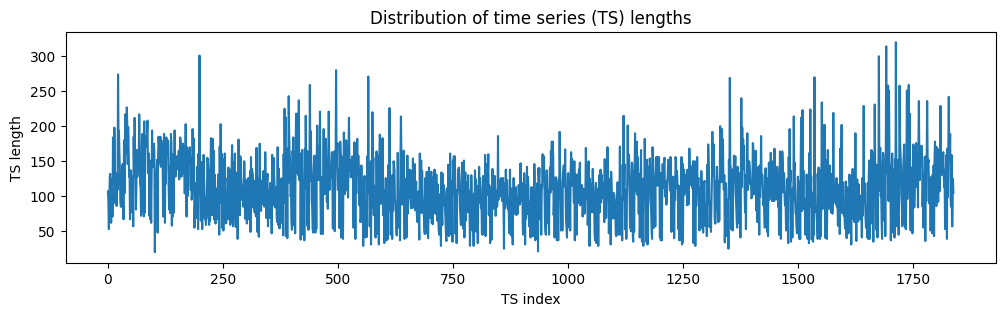

In [3]:
import numpy as np

from tslearn.utils import ts_size

for label in np.unique(labels):
  print(f"{np.count_nonzero(labels==label)} TS for class {label}")

ts_sizes = [ts_size(ts) for ts in dataset]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(np.arange(0, dataset.shape[0]), ts_sizes)
ax.set_title("Distribution of time series (TS) lengths")
ax.set_xlabel("TS index")
ax.set_ylabel("TS length")


## 2. Preprocessing

Preprocessing time series data is crucial for optimal model performance. Unlike tabular data, time series require specialized techniques that respect temporal structure.

`tslearn` provides three key preprocessing tools:
- *Imputation* — Handle missing values while preserving temporal continuity
- *Resampling* — Standardize series lengths for consistent computations
- *Scaling* — Normalize feature magnitudes for fair distance comparisons


See the [documentation](https://tslearn.readthedocs.io/en/stable/gen_modules/tslearn.preprocessing.html) for more details.

### 2.1 Missing data imputation

IMUs have faced bad times during the experiment, and some samples are missing (you may set the `verbose` parameter of `get_X_y` to display missing timestamps).

Imputing missing values in time series preserves temporal continuity. `tslearn` implements a few methods of imputing time series values, including *mean*, *median*, *ffill*, *bfill*, *linear*, *constant*, or you can provide a custom imputing method.

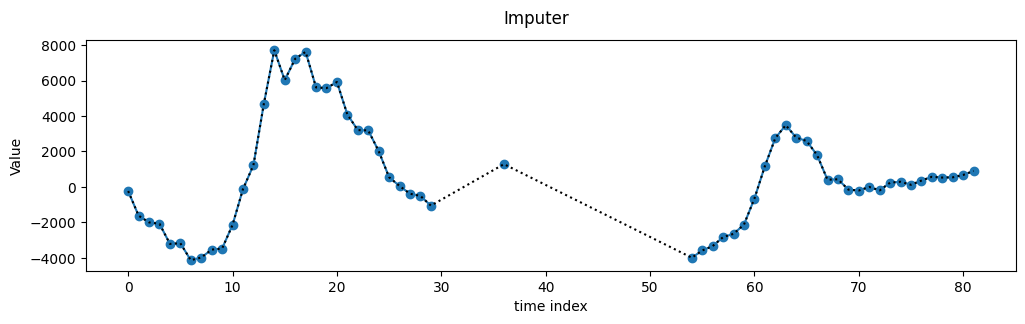

In [4]:
# Imputer: this particular time series has missing data
# corresponding to the lla imu (feature 6 to 11)
task = 1081
feature = 10

from tslearn.preprocessing import TimeSeriesImputer
imputed = TimeSeriesImputer(method="linear", keep_trailing_nans=True).fit_transform(dataset[task, :, feature].reshape(1, -1, 1))

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 3))
fig.suptitle('Imputer')
plt.plot(dataset[task, :, feature], '-o')
plt.plot(imputed.reshape(-1), 'k:')
plt.ylabel("Value")
plt.xlabel("time index")
plt.show()

💡 Take some time to play with the [TimeSeriesImputer](https://tslearn.readthedocs.io/en/stable/gen_modules/preprocessing/tslearn.preprocessing.TimeSeriesImputer.html#tslearn.preprocessing.TimeSeriesImputer) parameters

### 2.2 Time series resampling

Resampling enforces a common temporal length across time series, enabling consistent preprocessing and distance computations.  By default, the size of the longest time series of dataset is used. If the target size is specified then the `tslearn` [TimeSeriesResampler](https://tslearn.readthedocs.io/en/stable/gen_modules/preprocessing/tslearn.preprocessing.TimeSeriesResampler.html#tslearn.preprocessing.TimeSeriesResampler) either upsamples or downsamples the time series.

In [5]:
from tslearn.preprocessing import TimeSeriesResampler
from tslearn.utils import ts_size

resampled_dataset = TimeSeriesResampler(sz=300).fit_transform(dataset)
ts_size(dataset[0]), ts_size(resampled_dataset[0]), dataset.shape[1], resampled_dataset.shape[1]

(106, 300, 319, 300)

💡 You may want to visualize resampling impact on data

### 2.3 Feature scaling

Scaling ensures feature magnitudes are comparable so no single sensor or axis dominates distance computations or model training. Choose `tslearn`'s [mean–variance](https://tslearn.readthedocs.io/en/stable/gen_modules/preprocessing/tslearn.preprocessing.TimeSeriesScalerMeanVariance.html#tslearn.preprocessing.TimeSeriesScalerMeanVariance) or [min–max](https://tslearn.readthedocs.io/en/stable/gen_modules/preprocessing/tslearn.preprocessing.TimeSeriesScalerMinMax.html) scaling, and control the scope with per timeseries (compute stats per series), per feature (compute stats per feature across all series), or set both False to compute statistics globally across the entire dataset.

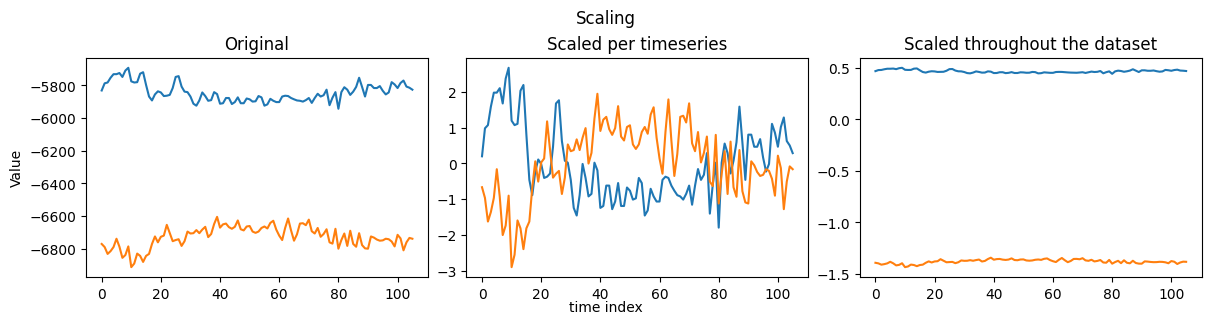

In [6]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
per_ts = TimeSeriesScalerMeanVariance(per_timeseries=True, per_feature=True).fit_transform(dataset)
all_ts = TimeSeriesScalerMeanVariance(per_timeseries=False, per_feature=True).fit_transform(dataset)

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle('Scaling')
fig.text(0.5, -0.02, 'time index', ha='center')
ax = axs[0]
ax.set_ylabel("Value")
ax.plot(dataset[0, :, 6])
ax.plot(dataset[0, :, 7])
ax.set_title('Original')
ax = axs[1]
ax.plot(per_ts[0, :, 6])
ax.plot(per_ts[0, :, 7])
ax.set_title('Scaled per timeseries')
ax = axs[2]
ax.plot(all_ts[0, :, 6])
ax.plot(all_ts[0, :, 7])
ax.set_title('Scaled throughout the dataset')
plt.show()


## 3. Clustering

Clustering groups similar time-series instances to discover patterns or behaviors without labels; for time series this typically means using sequence-aware distances (e.g., [DTW (dynamic time warping)](https://tslearn.readthedocs.io/en/stable/user_guide/dtw.html)).

See the [documentation](https://tslearn.readthedocs.io/en/stable/user_guide/clustering.html) for more details.

In [7]:
task_labels = ["walk", "standup", "sitdown"]
volunteers =  [1]
imus = None
feature_labels = ["x-acc", "y-acc", "z-acc"]

n_clusters = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, feature_labels=feature_labels, task_labels=task_labels)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(72, 226, 18) ['walk: 41', 'standup: 17', 'sitdown: 14']


### 3.1 Euclidean $k$-means (`sklearn`)

To establish a base model, let's convert series to fixed‑length representations and apply standard non‑time‑series clustering method.

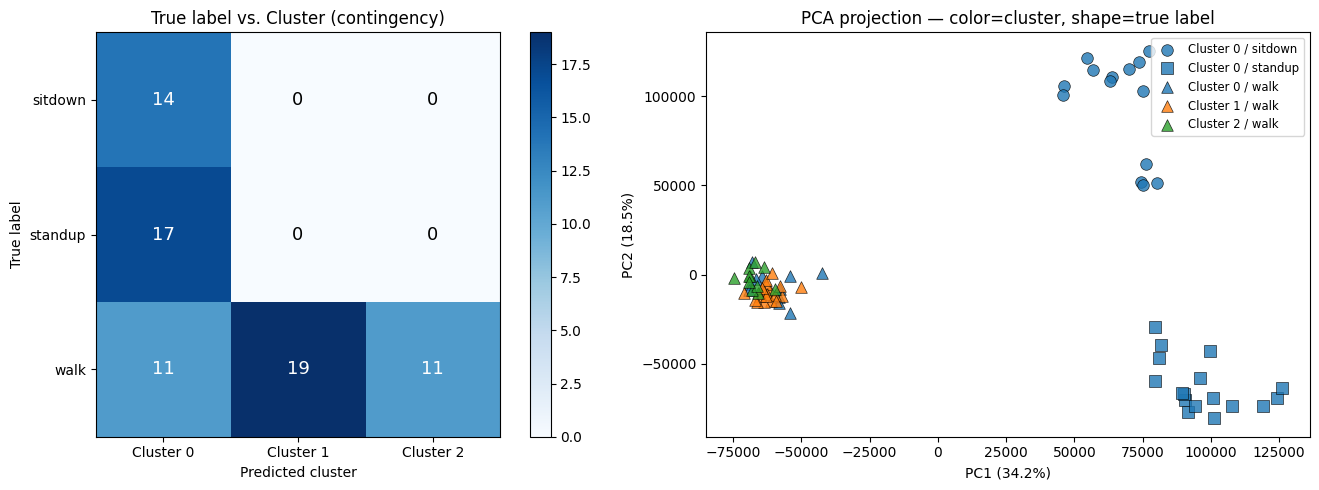

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing  import StandardScaler
from sklearn.cluster import KMeans

from tslearn.utils import to_sklearn_dataset

from utils import visualize_clustering_results

sk_dataset = to_sklearn_dataset(dataset)
sk_dataset = SimpleImputer(strategy="constant", fill_value =0.0).fit_transform(sk_dataset)
sk_dataset = StandardScaler().fit_transform(sk_dataset)
cl_sk_kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(sk_dataset)

visualize_clustering_results(cl_sk_kmeans, dataset, labels)

💡 How does `tslearn`'s scaling utilities compare to what scikit-learn offers? In other words, what is the actual difference between `tslearn` rescaling and what is done in the cell above?

### 3.2 Dynamic Time Warping (DTW) $k$-means (`tslearn`)

Now let's try `tslearn`'s [time‑series‑aware implementation](https://tslearn.readthedocs.io/en/stable/gen_modules/clustering/tslearn.clustering.TimeSeriesKMeans.html#tslearn.clustering.TimeSeriesKMeans) of the $k$-means algorithm, which clusters series by their temporal patterns rather than by point-wise, flattened similarity. You can use the same visualization function `visualize_clustering_results` to compare the results.

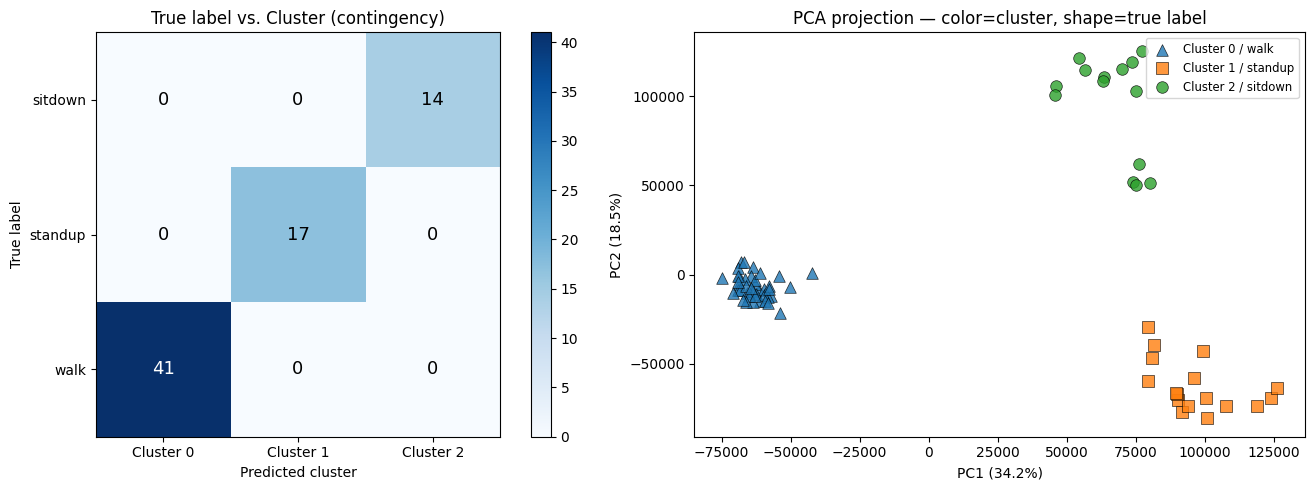

In [9]:
# perform KMEANS clustering using tslearn and visualize results
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesImputer, TimeSeriesScalerMeanVariance

tslearn_dataset = TimeSeriesImputer(keep_trailing_nans=True).fit_transform(dataset)
tslearn_dataset = TimeSeriesScalerMeanVariance(per_timeseries=False, per_feature=False).fit_transform(tslearn_dataset)
cl_ts_kmeans = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=0).fit(tslearn_dataset)

visualize_clustering_results(cl_ts_kmeans, dataset, labels)

💡 Reflect on the difference in the results between point-wise and temporal models.

💡 Given what you know about the data (dataset of daily activities), and considering that only `x-acc`, `y-acc` and `z-acc` features are kept in this experiment, do you expect that scaling should be performed per timeseries? Per feature?

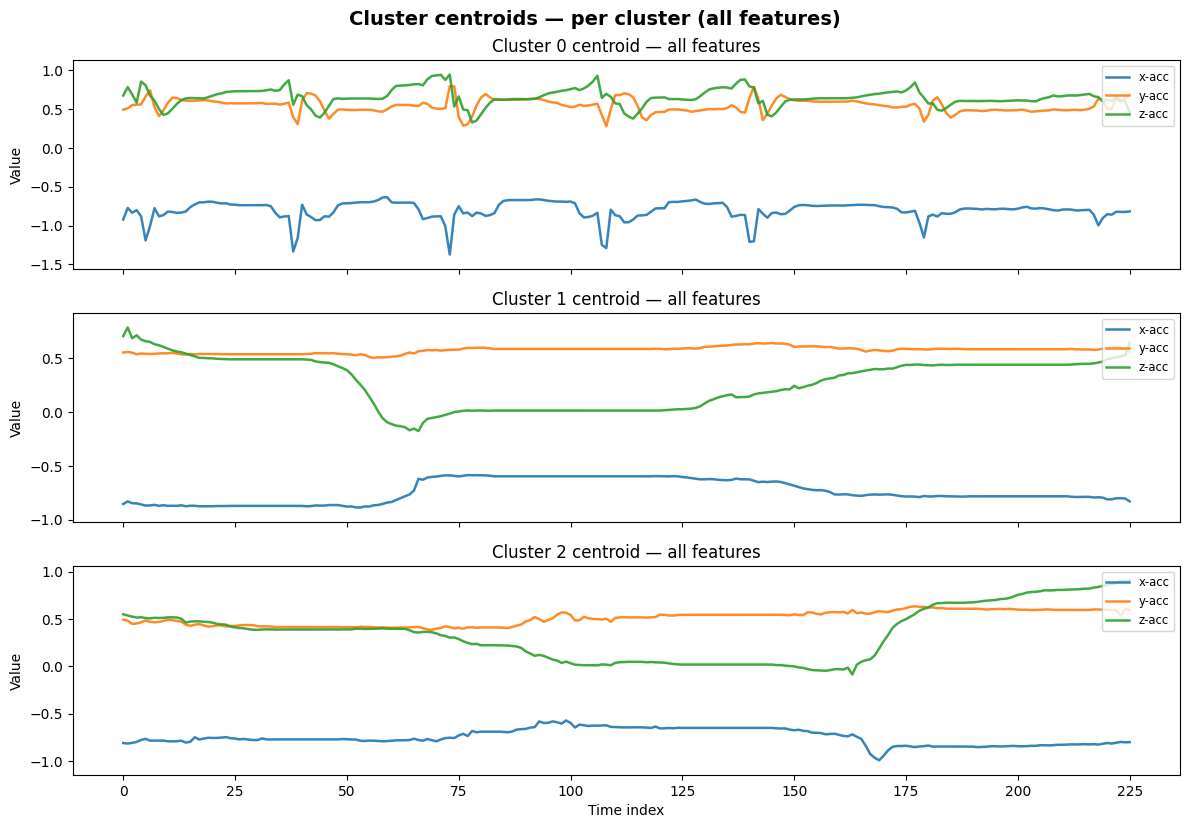

In [10]:
# You might want to take a look at the computed attributes after clustering is performed and
# plot the cluster centroids to see the patterns that were learned by the model.
from utils import visualize_cluster_centroids

# Write your code here

visualize_cluster_centroids(cl_ts_kmeans, feature_labels)

### 3.3 Evaluating Cluster Quality

The *silhouette score* measures how well each series fits its assigned cluster compared with other clusters by combining cohesion (intra‑cluster distance) and separation (nearest‑cluster distance) into a single value in [-1, 1], where values near +1 indicate well‑separated, compact clusters and values near or below 0 indicate overlapping or misassigned points.

The silhouette score is computed as as scaled difference between average inter-cluster distance and average intra-cluster distance.
It hence measures the compacity of clusters with respect to a given metric.

Use it to compare clustering algorithms or hyperparameters (e.g., number of clusters, DTW vs. Euclidean) and to get an interpretable quality metric.

⚠️ *Note:* Computing [silhouette with DTW](https://tslearn.readthedocs.io/en/stable/gen_modules/clustering/tslearn.clustering.silhouette_score.html) can be expensive due to pairwise distance calculations.

In [11]:
from tslearn.clustering import silhouette_score
from sklearn.metrics import silhouette_score as sk_silhouette_score

sil_score = silhouette_score(tslearn_dataset, cl_ts_kmeans.labels_, metric="dtw")
sk_sil_score = sk_silhouette_score(sk_dataset, cl_sk_kmeans.labels_, metric='euclidean')

print(f"Silhouette score for DTW KMeans clustering: {sil_score:.4f}")
print(f"Silhouette score for euclidean KMeans clustering: {sk_sil_score:.4f}")

Silhouette score for DTW KMeans clustering: 0.4262
Silhouette score for euclidean KMeans clustering: 0.2016


## 4 Classification

Time-series classification assigns predefined labels to sequences based on their temporal patterns. Unlike clustering, we have ground-truth labels to train and evaluate our models.

To showcase time‑series‑aware classification models we shall try to predict activity labels from the ADL dataset.

We'll classify 6 activities using data from one volunteer, one IMU, and one measurement to keep training times manageable while demonstrating key concepts.

In [12]:
task_labels = ["sitdown", "drinkglass", "walk", "opendoor", "cleantable", "brushteeth"]
volunteers =  [1]
imus = ["back"]
feature_labels = ["z-acc"]
n_classes = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, feature_labels=feature_labels, task_labels=task_labels)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(129, 272, 1) ['sitdown: 14', 'drinkglass: 24', 'walk: 41', 'opendoor: 17', 'cleantable: 18', 'brushteeth: 15']


In [13]:
# Partition the data into train/test sets using stratified sampling from scikit-learn.
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)
for x in np.unique(labels):
    print(x,
          "train", len(np.argwhere(train_labels==x)),
          "test", len(np.argwhere(test_labels==x)),
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)

brushteeth train 10 test 5 total 15 test% 0.33
cleantable train 12 test 6 total 18 test% 0.33
drinkglass train 17 test 7 total 24 test% 0.29
opendoor train 12 test 5 total 17 test% 0.29
sitdown train 10 test 4 total 14 test% 0.29
walk train 29 test 12 total 41 test% 0.29


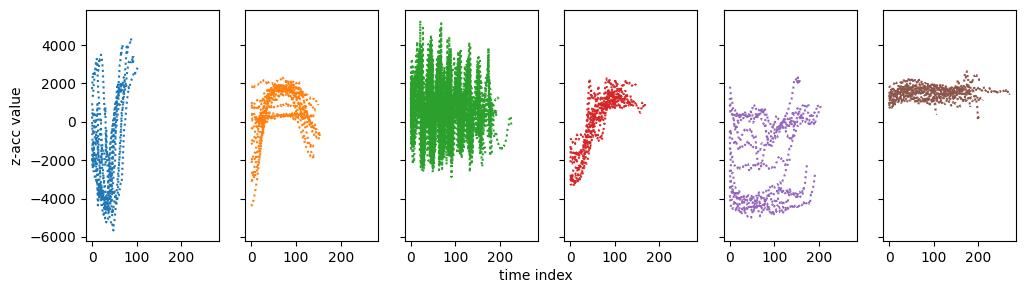

In [14]:
# Visualize data
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, n_classes, figsize=(12, 3), sharex=True, sharey=True)
axs[0].set_ylabel('z-acc value')
fig.text(0.5, -0.02, 'time index', ha='center')
colors = plt.get_cmap("tab10").colors

for i in range(n_classes):
    for x in train_data[train_labels==task_labels[i]]:
        axs[i].plot(x, linestyle=":", color=colors[i])

### 4.1 Euclidean $k$-NN (`sklearn`)

To establish a baseline, we'll flatten time series into fixed-length feature vectors and apply standard k-nearest neighbors classification. This approach uses Euclidean distance on raw feature values.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

from tslearn.preprocessing import TimeSeriesResampler
from tslearn.utils import to_sklearn_dataset

equal_size_train_data = TimeSeriesResampler().fit_transform(train_data)
sk_train_data = to_sklearn_dataset(equal_size_train_data)

sk_knn = KNeighborsClassifier()
parameters = {'n_neighbors': list(range(1, 6))}
sk_grid = GridSearchCV(sk_knn, parameters).fit(sk_train_data, train_labels)

mean_scores = np.array(sk_grid.cv_results_["mean_test_score"])
print(mean_scores)

[0.78888889 0.65555556 0.65555556 0.6        0.62222222]


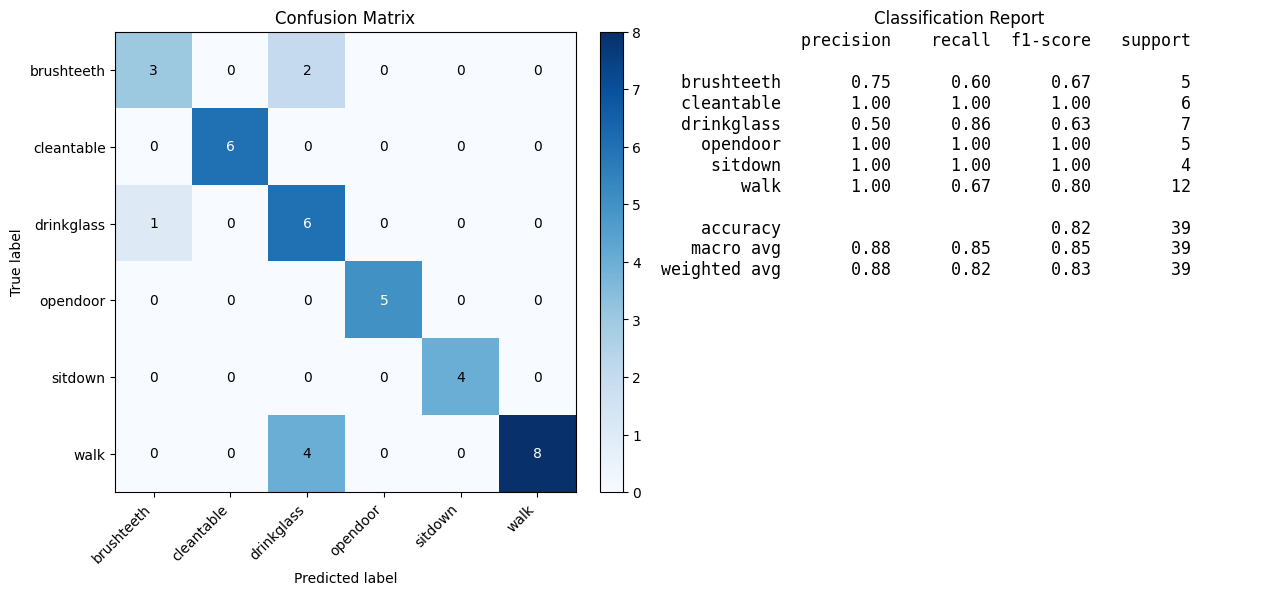

In [16]:
from utils import visualize_classification_results

equal_size_test_data = TimeSeriesResampler(equal_size_train_data.shape[1]).fit_transform(test_data)
sklearn_test_data = to_sklearn_dataset(equal_size_test_data)
y_pred_euclidean = sk_grid.predict(sklearn_test_data)

visualize_classification_results(sk_grid, test_labels, y_pred_euclidean)

### 4.2 DTW $k$-NN (`tslearn`)

Now let's train a classifier using `tslearn`'s [time‑series‑aware KNN](https://tslearn.readthedocs.io/en/stable/gen_modules/neighbors/tslearn.neighbors.KNeighborsTimeSeriesClassifier.html#tslearn.neighbors.KNeighborsTimeSeriesClassifier) (e.g., DTW distance) so classification matches series by temporal shape rather than point‑wise similarity and handles slight variations in timing and speed.

Key parameters are `metric="dtw"` and number of neighbors `n_neighbors` that should be tuned via cross_validation.

Use `visualize_classification_results` to inspect per‑class performance.

In [17]:
# Perform KNN classification using tslearn model and and scikit-learn GridSearchCV
# You might want to take a look at the computed attributes after classification is performed
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

ts_knn = KNeighborsTimeSeriesClassifier()
parameters = {'n_neighbors': list(range(1, 6))}
tslearn_grid = GridSearchCV(ts_knn, parameters).fit(train_data, train_labels)

mean_scores = np.array(tslearn_grid.cv_results_["mean_test_score"])
print(mean_scores)

[0.94444444 0.92222222 0.91111111 0.87777778 0.88888889]


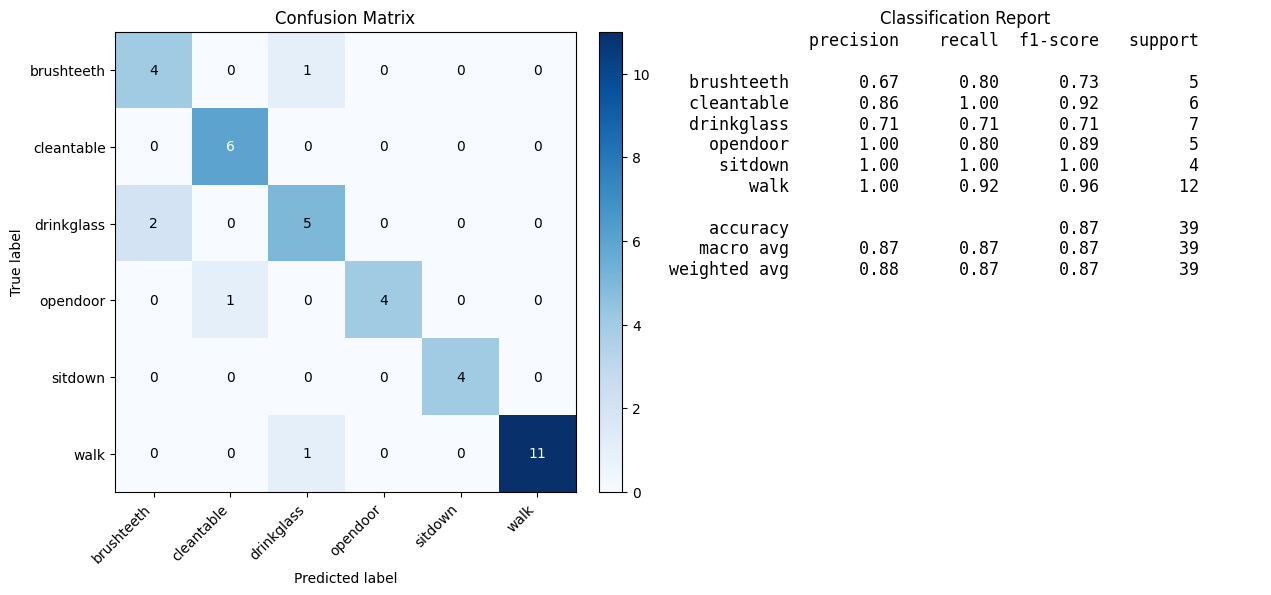

In [18]:
# Visualize the confusion matrix and classification report
from utils import visualize_classification_results

y_pred_dtw = tslearn_grid.predict(test_data)
visualize_classification_results(tslearn_grid, test_labels, y_pred_dtw)

### 4.3 Shapelets

Shapelets are short, discriminative subsequences that best distinguish between classes. Unlike the previous classifier, which compares entire series, shapelets focus on *local patterns* that characterize each activity.

`tslearn` implements *Learning Time Series Shapelets* algorithm, which learns shapelet patterns directly from training data and trains a classifier that uses the distance from each series to each shapelet as features.
This model is an instance of a neural network whose parameters are the shapelet values and the weights associated to the distance features.
`tslearn` implementation relies on the `keras` library.

See the [documentation](https://tslearn.readthedocs.io/en/stable/user_guide/shapelets.html) for more details.

This makes the approach especially interpretable and useful when class differences are driven by local patterns. You can plot the learned shapelets and see where they match the series by calling the provided `visualize_shapelets` or `visualize_shapelet_matches` utility functions.

We'll use 2 activities and 1 feature to reduce training time and simplify interpretation.

In [19]:
task_labels = ["standup", "sitdown"]
volunteers =  [1]
n_classes = len(task_labels)
imus = ["rt"]
feature_labels = ["x-acc"]

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, feature_labels=feature_labels, task_labels=task_labels, min_size=30)
labels = np.array(tasks)[:, 2]
print(dataset.shape, [f"{task_label}: {np.count_nonzero(labels == task_label)}" for task_label in task_labels])

(31, 103, 1) ['standup: 17', 'sitdown: 14']


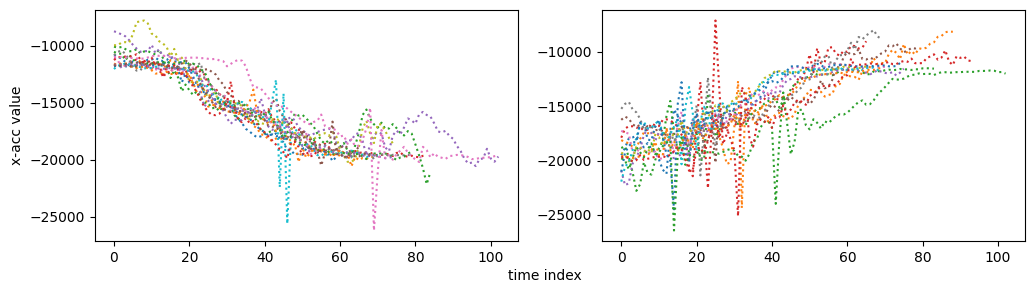

In [20]:
# Visualize data
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, n_classes, figsize=(12, 3))
fig.text(0.5, -0.02, 'time index', ha='center')
axs[0].set_ylabel('x-acc value')

for i in range(n_classes):
    for x in dataset[labels==task_labels[i]]:
        axs[i].plot(x, linestyle=':')

In [21]:
from sklearn.model_selection import train_test_split
train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)
for x in np.unique(labels):
    print(x,
          "train", len(np.argwhere(train_labels==x)),
          "test", len(np.argwhere(test_labels==x)),
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)


sitdown train 9 test 5 total 14 test% 0.36
standup train 12 test 5 total 17 test% 0.29


The key parameter n_shapelets_per_size specifies how many shapelets to learn for each length in a form of a dictionary. E.g. {30: 2, 10: 3} mean asking to learn 2 shapelets of length 30 and 3 of length 10.

Shorter shapelets capture brief, distinctive motions, longer shapelets capture extended patterns. More shapelets lead to more expressive but slower training.

⚠️ Note: As for most neural network models, training a Shapelet model can be quite slow. Start with few shapelets and increase as needed.


In [22]:
import torch
from tslearn.shapelets import LearningShapelets

from utils import visualize_classification_results

shapelet_clf = LearningShapelets(
    n_shapelets_per_size={30: 2},
    scale=True,
    random_state=42 if torch.cuda.device_count() else 0,
    max_iter=300,
    batch_size=7,
    optimizer="adam"
).fit(train_data, train_labels)

y_pred_shapelets = shapelet_clf.predict(test_data)

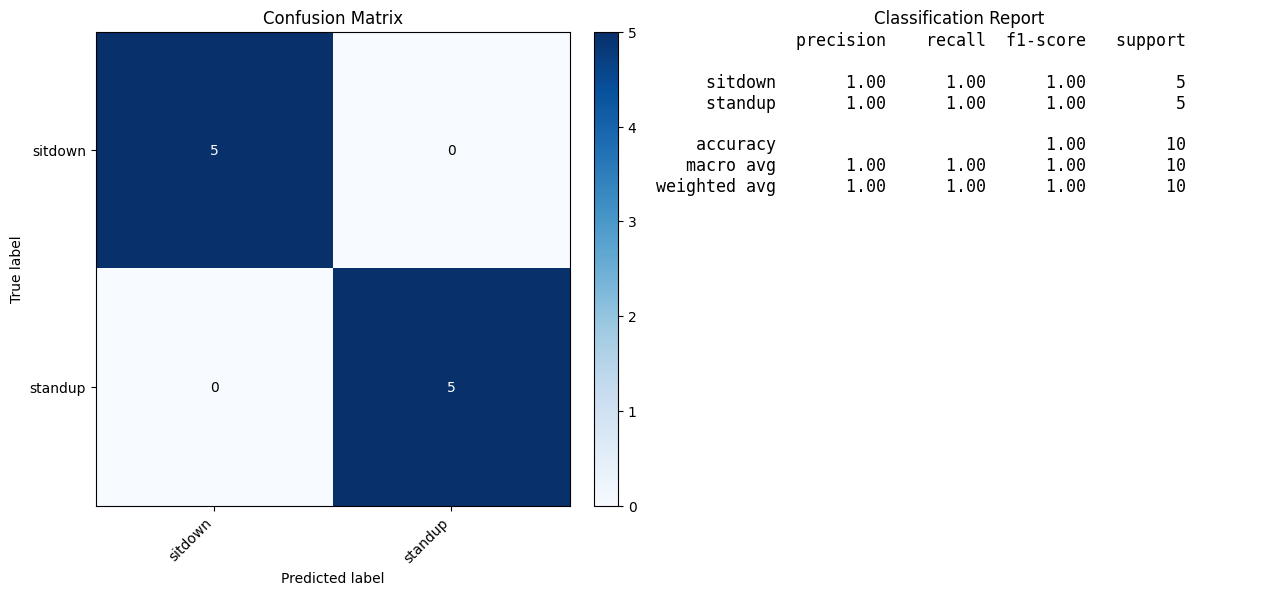

In [23]:
visualize_classification_results(shapelet_clf, test_labels, y_pred_shapelets)

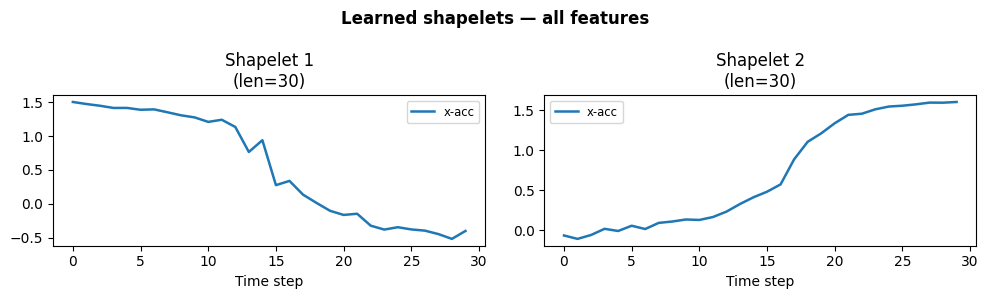

In [24]:
# visualize learned shapelets (one plot per shapelet, all features in each plot)
from utils import visualize_shapelets

visualize_shapelets(shapelet_clf, feature_labels=feature_labels)

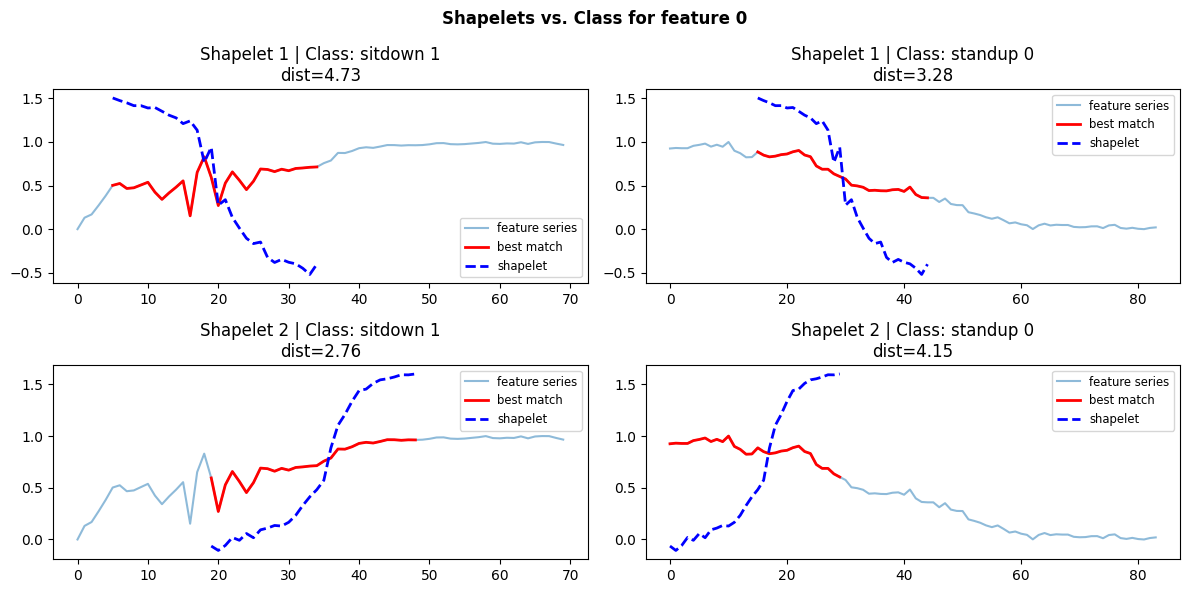

In [25]:
from tslearn.preprocessing import TimeSeriesScalerMinMax

from utils import visualize_shapelet_matches

visualize_shapelet_matches(shapelet_clf, TimeSeriesScalerMinMax().fit_transform(train_data), train_labels, show_feature=0)

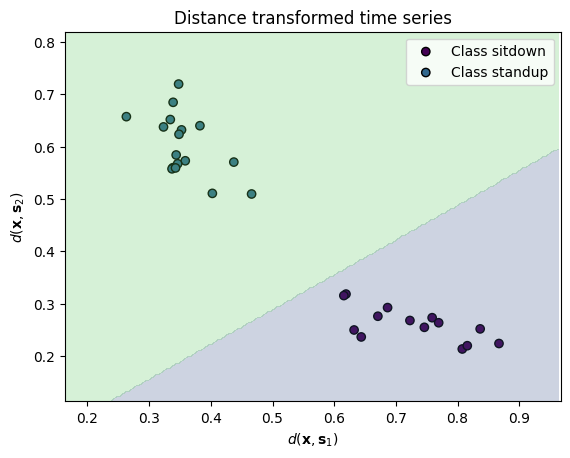

In [26]:
from utils import visualize_shapelet_projection

visualize_shapelet_projection(shapelet_clf, dataset, labels)

### 4.4 Exercise: Large scale shapelets

Build a shapelet classifier for more activities and multiple features.

Shapelets benefit from GPU acceleration. If you are using colab environment, you might want to connect to a GPU.

Start with the same shapelet configuration (`{30: 2}`). Experiment with different configurations (e.g., `{30: 2, 15: 3}`)

⏱️ Expected training time: 1-3 minutes depending on configuration

In [27]:
# Given the following dataset, perform classification using the shapelet models

task_labels = ["walk", "standup", "sitdown"]
volunteers =  None
imus = ["back"]
feature_labels = None
n_classes = len(task_labels)

dataset, tasks = get_X_y(volunteers=volunteers, imus=imus, feature_labels=feature_labels, task_labels=task_labels, min_size=30)
labels = np.array(tasks)[:, 2]
train_data, test_data, train_labels, test_labels = train_test_split(
    dataset, labels, test_size=0.3, random_state=0, stratify=labels, shuffle=True
)

In [29]:
for x in np.unique(labels):
    print(x,
          "train", len(np.argwhere(train_labels==x)),
          "test", len(np.argwhere(test_labels==x)),
          "total", len(np.argwhere(labels==x)),
          "test%", np.round((len(np.argwhere(test_labels==x)) / len(np.argwhere(labels==x))), 2) if len(np.argwhere(labels==x)) > 0 else 0.0)

sitdown train 94 test 41 total 135 test% 0.3
standup train 117 test 50 total 167 test% 0.3
walk train 273 test 117 total 390 test% 0.3


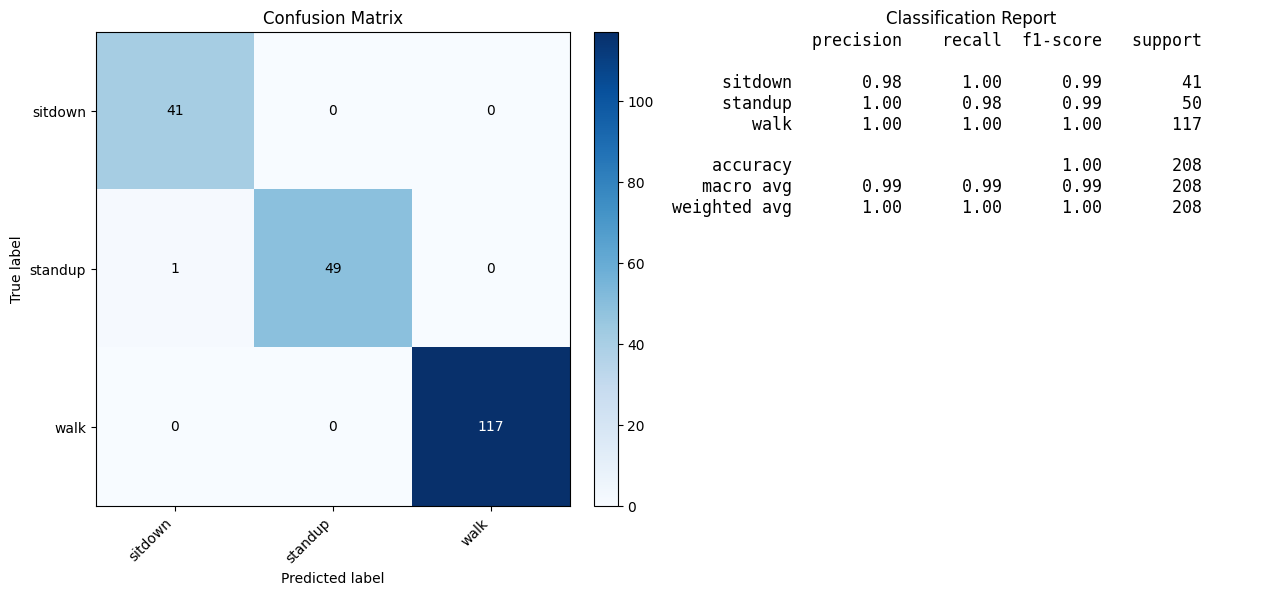

In [31]:
from tslearn.shapelets import LearningShapelets

shapelet_clf = LearningShapelets(
    n_shapelets_per_size={30: 5},
    scale=True,
    random_state=0,
    max_iter=500,
    batch_size=30,
    optimizer="adam"
).fit(train_data, train_labels)

y_pred_shapelets = shapelet_clf.predict(test_data)

visualize_classification_results(shapelet_clf, test_labels, y_pred_shapelets)

💡 Reflect on trade-offs you observe between shapelet configuration, training time, and accuracy.